# D2 Discussion Workbook: Explore Data Set Features & Engage

Use this notebook to run each required item for your D2 discussion post.

What this notebook does:
- Loads your dataset
- Checks missing values
- Builds target and feature histograms
- Characterizes histogram shapes
- Applies and explains a recommended transformation
- Generates a ready-to-paste draft response

In [17]:
# Part 0: Configuration
from pathlib import Path

DATA_PATH = Path('../data/raw/diabetes.csv')
KAGGLE_LINK = (
    'https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset'
)
PREFERRED_NAME = 'Angie'

# D2 prompt variables
TARGET_COL = 'Diabetes_binary'
X_COL = 'BMI'

# Output locations for screenshots
OUTPUT_DIR = Path('../docs/images')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TARGET_PNG = OUTPUT_DIR / 'd2_target_hist.png'
X_PNG = OUTPUT_DIR / 'd2_x_hist.png'

print('Data path:', DATA_PATH.resolve())
print('Target histogram output:', TARGET_PNG.resolve())
print('X histogram output:', X_PNG.resolve())

Data path: C:\Repos\Applied Machine Learning (44670)\ml-01-intro\data\raw\diabetes.csv
Target histogram output: C:\Repos\Applied Machine Learning (44670)\ml-01-intro\docs\images\d2_target_hist.png
X histogram output: C:\Repos\Applied Machine Learning (44670)\ml-01-intro\docs\images\d2_x_hist.png


In [18]:
# Part 1: Imports and load data
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv(DATA_PATH)
print('Rows, Columns:', df.shape)
display(df.head())

Rows, Columns: (70692, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [19]:
# Part 2: Column view and missing values
column_summary = pd.DataFrame(
    {
        'dtype': df.dtypes.astype(str),
        'missing_count': df.isna().sum(),
        'missing_pct': (df.isna().mean() * 100).round(2),
        'n_unique': df.nunique(),
    }
).sort_values(['missing_count', 'n_unique'], ascending=[False, False])

display(column_summary)

,dtype,missing_count,missing_pct,n_unique
BMI,float64,0,0.0,80
MentHlth,float64,0,0.0,31
PhysHlth,float64,0,0.0,31
Age,float64,0,0.0,13
Income,float64,0,0.0,8
Education,float64,0,0.0,6
GenHlth,float64,0,0.0,5
Diabetes_binary,float64,0,0.0,2
HighBP,float64,0,0.0,2
HighChol,float64,0,0.0,2


In [20]:
# Part 3: Helper to characterize histogram shape
def characterize_hist(series: pd.Series) -> str:
    s = series.dropna()
    n_unique = s.nunique()

    # Binary/discrete two-value columns are effectively bimodal in count plots
    if n_unique == 2:
        return 'Bimodal (two bars/peaks for two classes)'

    if pd.api.types.is_numeric_dtype(s):
        skew = s.skew()
        if abs(skew) < 0.35:
            return 'Approximately normal'
        if skew >= 0.35:
            return 'Skewed right (many lower values with a long high-value tail)'
        return 'Skewed left (many higher values with a long low-value tail)'

    top_share = s.value_counts(normalize=True, dropna=False).iloc[0]
    if top_share > 0.85:
        return 'Something else: highly imbalanced categorical distribution'
    return 'Something else: non-numeric categorical distribution'

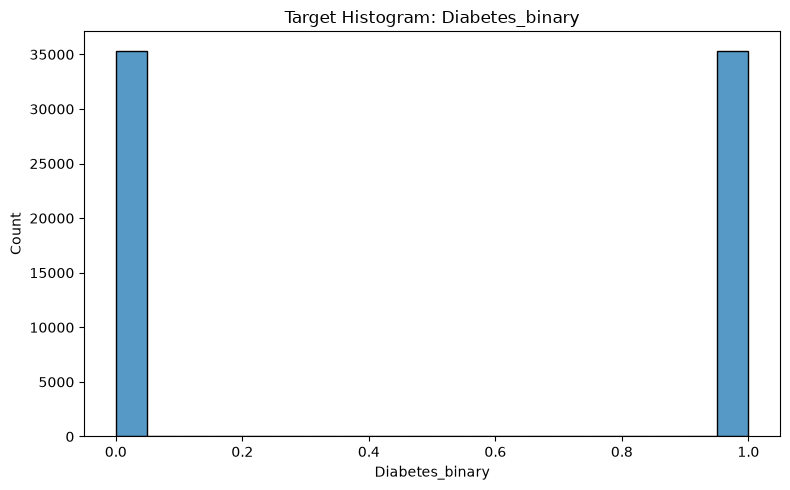

Target missing values: 0
Target histogram characterization: Bimodal (two bars/peaks for two classes)
Saved figure: ..\docs\images\d2_target_hist.png


In [21]:
# Part 4: Target y analysis
y_missing = int(df[TARGET_COL].isna().sum())
y_shape = characterize_hist(df[TARGET_COL])

plt.figure(figsize=(8, 5))
sns.histplot(df[TARGET_COL], kde=False, bins=20)
plt.title(f'Target Histogram: {TARGET_COL}')
plt.xlabel(TARGET_COL)
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(TARGET_PNG, dpi=150)
plt.show()

print('Target missing values:', y_missing)
print('Target histogram characterization:', y_shape)
print('Saved figure:', TARGET_PNG)

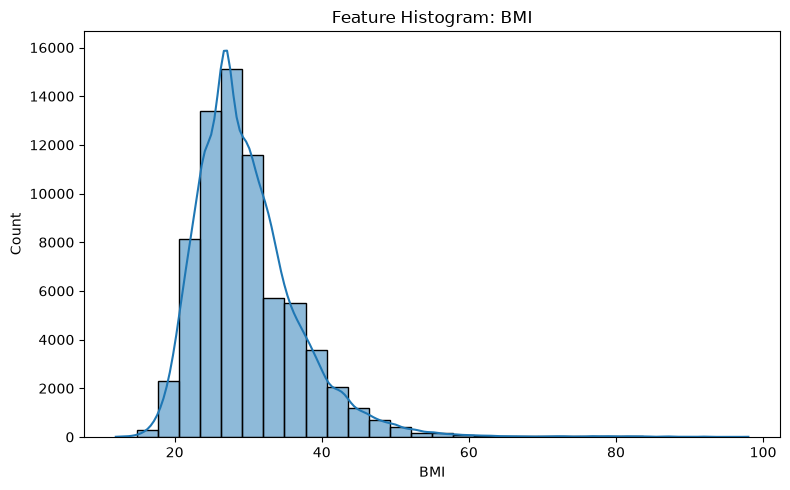

X missing values: 0
X histogram characterization: Skewed right (many lower values with a long high-value tail)
Saved figure: ..\docs\images\d2_x_hist.png


In [22]:
# Part 5: Independent variable x analysis
x_missing = int(df[X_COL].isna().sum())
x_shape = characterize_hist(df[X_COL])

plt.figure(figsize=(8, 5))
sns.histplot(df[X_COL], kde=True, bins=30)
plt.title(f'Feature Histogram: {X_COL}')
plt.xlabel(X_COL)
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(X_PNG, dpi=150)
plt.show()

print('X missing values:', x_missing)
print('X histogram characterization:', x_shape)
print('Saved figure:', X_PNG)

In [23]:
# Part 6: Recommended transformation (Age code -> age groups + one-hot encoding)
# BRFSS age coding commonly uses grouped category codes.
age_map = {
    1: '18-24',
    2: '25-29',
    3: '30-34',
    4: '35-39',
    5: '40-44',
    6: '45-49',
    7: '50-54',
    8: '55-59',
    9: '60-64',
    10: '65-69',
    11: '70-74',
    12: '75-79',
    13: '80+',
}

if 'Age' in df.columns:
    df['Age_group'] = df['Age'].round().astype('Int64').map(age_map).fillna('Unknown')
    age_dummies = pd.get_dummies(df['Age_group'], prefix='AgeGroup', dtype=int)

    transformed_preview = pd.concat(
        [df[['Age', 'Age_group']].head(10), age_dummies.head(10)], axis=1
    )
    display(transformed_preview)

    print('Transformation complete: Age -> Age_group + one-hot columns')
    print('New one-hot columns:', [c for c in age_dummies.columns][:8], '...')
else:
    print('Column Age not found. Pick another transformation for your dataset.')

,Age,Age_group,AgeGroup_18-24,AgeGroup_25-29,AgeGroup_30-34,AgeGroup_35-39,AgeGroup_40-44,AgeGroup_45-49,AgeGroup_50-54,AgeGroup_55-59,AgeGroup_60-64,AgeGroup_65-69,AgeGroup_70-74,AgeGroup_75-79,AgeGroup_80+
0,4.0,35-39,0,0,0,1,0,0,0,0,0,0,0,0,0
1,12.0,75-79,0,0,0,0,0,0,0,0,0,0,0,1,0
2,13.0,80+,0,0,0,0,0,0,0,0,0,0,0,0,1
3,11.0,70-74,0,0,0,0,0,0,0,0,0,0,1,0,0
4,8.0,55-59,0,0,0,0,0,0,0,1,0,0,0,0,0
5,1.0,18-24,1,0,0,0,0,0,0,0,0,0,0,0,0
6,13.0,80+,0,0,0,0,0,0,0,0,0,0,0,0,1
7,6.0,45-49,0,0,0,0,0,1,0,0,0,0,0,0,0
8,3.0,30-34,0,0,1,0,0,0,0,0,0,0,0,0,0
9,6.0,45-49,0,0,0,0,0,1,0,0,0,0,0,0,0


Transformation complete: Age -> Age_group + one-hot columns
New one-hot columns: ['AgeGroup_18-24', 'AgeGroup_25-29', 'AgeGroup_30-34', 'AgeGroup_35-39', 'AgeGroup_40-44', 'AgeGroup_45-49', 'AgeGroup_50-54', 'AgeGroup_55-59'] ...


## Summary of Activity

This section summarizes what has been completed in the notebook and reports the key outputs produced during this run.

In [24]:
# Summary section: concise report of completed activity

summary_lines = []
summary_lines.append('Notebook Activity Summary')
summary_lines.append('=' * 28)

# Data and configuration
summary_lines.append(f"Name: {PREFERRED_NAME}")
summary_lines.append(f"Data file: {DATA_PATH}")
summary_lines.append(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
summary_lines.append(f"Target feature (y): {TARGET_COL}")
summary_lines.append(f"Independent feature (x): {X_COL}")

# Data quality checks
summary_lines.append('')
summary_lines.append('Data quality checks completed:')
summary_lines.append(f"- Missing values in y ({TARGET_COL}): {y_missing}")
summary_lines.append(f"- Missing values in x ({X_COL}): {x_missing}")

# Histogram characterization
summary_lines.append('')
summary_lines.append('Histogram characterization completed:')
summary_lines.append(f"- y histogram: {y_shape}")
summary_lines.append(f"- x histogram: {x_shape}")

# Artifacts
summary_lines.append('')
summary_lines.append('Saved output images:')
summary_lines.append(f"- Target histogram: {TARGET_PNG}")
summary_lines.append(f"- X histogram: {X_PNG}")

# Transformation status
summary_lines.append('')
if 'Age_group' in df.columns:
    summary_lines.append(
        'Transformation completed: Age -> Age_group + one-hot encoding.'
    )
    summary_lines.append(f"One-hot columns created: {len(age_dummies.columns)}")
else:
    summary_lines.append('Transformation not completed (Age_group column not found).')

summary_text = '\n'.join(summary_lines)
print(summary_text)

Notebook Activity Summary
Name: Angie
Data file: ..\data\raw\diabetes.csv
Dataset shape: 70692 rows x 23 columns
Target feature (y): Diabetes_binary
Independent feature (x): BMI

Data quality checks completed:
- Missing values in y (Diabetes_binary): 0
- Missing values in x (BMI): 0

Histogram characterization completed:
- y histogram: Bimodal (two bars/peaks for two classes)
- x histogram: Skewed right (many lower values with a long high-value tail)

Saved output images:
- Target histogram: ..\docs\images\d2_target_hist.png
- X histogram: ..\docs\images\d2_x_hist.png

Transformation completed: Age -> Age_group + one-hot encoding.
One-hot columns created: 13
